## Football match modelling with penaltyblog

`penaltyblog` is a Python package for football analytics, written by Martin Eastwood, which bundles together tools for downloading match data, fitting statistical goal models, turning those models into betting-market probabilities, and decoding bookmaker odds. This is directly relevant to a betting company, because a model that turns team strengths into win/draw/loss probabilities is essentially how odds are set and checked. I downloaded and ran the "End-to-end Example" from the package documentation (https://penaltyblog.readthedocs.io/en/latest/models/example.html), which downloads three seasons of Premier League results and odds from football-data.co.uk, fits a Dixon-Coles model and then predicts a single fixture across many betting markets. I trimmed the printed output of the later cells to keep the notebook readable, and I did not include the section on saving and loading the model.

Below is the code I downloaded and ran initially.

In [1]:
import penaltyblog as pb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Download data from football-data.co.uk

In [16]:
df = pd.concat([
    pb.scrapers.FootballData("ENG Premier League", "2021-2022").get_fixtures(),
    pb.scrapers.FootballData("ENG Premier League", "2022-2023").get_fixtures(),
    pb.scrapers.FootballData("ENG Premier League", "2023-2024").get_fixtures(),
])

df.to_csv("premier_league_2021-2024.csv")

In [3]:
# The full table has over 100 columns (results plus odds from many bookmakers), so only show the key ones
df[["date", "team_home", "team_away", "goals_home", "goals_away"]].head()

,date,team_home,team_away,goals_home,goals_away
id,,,,,
1628812800---brentford---arsenal,2021-08-13,Brentford,Arsenal,2,0
1628899200---burnley---brighton,2021-08-14,Burnley,Brighton,1,2
1628899200---chelsea---crystal_palace,2021-08-14,Chelsea,Crystal Palace,3,0
1628899200---everton---southampton,2021-08-14,Everton,Southampton,3,1
1628899200---leicester---wolves,2021-08-14,Leicester,Wolves,1,0


In [4]:
print(df.shape)
df[["date", "team_home", "team_away", "goals_home", "goals_away"]].isnull().sum()

(1140, 112)


date          0
team_home     0
team_away     0
goals_home    0
goals_away    0
dtype: int64

# Fit a Dixon-Coles model

In [5]:
# Time-decay weights so that more recent matches have more influence on the fit
xi = 0.001
weights = pb.models.dixon_coles_weights(df["date"], xi=xi)

In [6]:
gh = df["goals_home"].values
ga = df["goals_away"].values
th = df["team_home"].values
ta = df["team_away"].values

In [7]:
model = pb.models.DixonColesGoalModel(gh, ga, th, ta, weights=weights)
model.fit()

print("Fitted:", model.fitted)
print("Log-likelihood:", model.loglikelihood)
print("AIC:", model.aic)
print("Number of params:", model.n_params)
print("First few params:", list(model.params.items())[:5])

Fitted: True
Log-likelihood: -2164.7411053585315
AIC: 4433.482210717063
Number of params: 52
First few params: [('attack_Arsenal', np.float64(1.4615428422357466)), ('attack_Aston Villa', np.float64(1.1840598523651162)), ('attack_Bournemouth', np.float64(0.9148345299646293)), ('attack_Brentford', np.float64(1.0526804112935573)), ('attack_Brighton', np.float64(1.0902286599235742))]


# Predict a specific fixture

In [8]:
home_team = "Man City"
away_team = "Liverpool"

# By default: max_goals=15 and normalize=True
pred = model.predict(home_team, away_team, max_goals=15, normalize=True)

print("P(Home win), P(Draw), P(Away win):", pred.home_draw_away)
print("Home xG:", pred.home_goal_expectation)
print("Away xG:", pred.away_goal_expectation)

P(Home win), P(Draw), P(Away win): [0.5680162783250318, 0.21832263999029294, 0.21366108168467546]
Home xG: 1.9360024003821235
Away xG: 1.1036812583491658


In [9]:
print("BTTS (Yes):", pred.btts_yes)
print("BTTS (No):", pred.btts_no)

# Totals: Under, Push, Over (an integer line can push, a half line cannot)
print("Totals 2.0 -> Under, Push, Over:", pred.totals(2.0))
print("Totals 2.5 -> Under, Push, Over:", pred.totals(2.5))

BTTS (Yes): 0.571301695599226
BTTS (No): 0.42869830440077406
Totals 2.0 -> Under, Push, Over: (0.19391976648538017, 0.22043857191218347, 0.5856416616024366)
Totals 2.5 -> Under, Push, Over: (0.41435833839756364, 0.0, 0.5856416616024366)


In [10]:
print("AH Home -0.5  (win prob only):", pred.asian_handicap("home", -0.5))
print("AH Home -0.25 (Win/Push/Lose):", pred.asian_handicap_probs("home", -0.25))
print("Double chance 1X:", pred.double_chance_1x)
print("DNB Home (conditional win prob):", pred.draw_no_bet_home)
print("P(Exact score 2-1):", pred.exact_score(2, 1))

AH Home -0.5  (win prob only): 0.5680162783250318
AH Home -0.25 (Win/Push/Lose): {'win': 0.5680162783250318, 'push': 0.10916131999514647, 'lose': 0.32282240167982196}
Double chance 1X: 0.7863389183153247
DNB Home (conditional win prob): 0.7266633362874652
P(Exact score 2-1): 0.0989709220733487


## My visualisations of the data

Below is code I wrote in order to create some new visualisations. The original example only prints numbers, so I focused on plots that answer questions a betting company would care about: how much margin do bookmakers build in, how strong is each team according to the model, what does the model think the likely scorelines are, and is the model any good compared with the bookmakers' own odds?

First, a boxplot of the bookmaker margin (the overround). This is the sum of the inverse decimal odds for home, draw and away, minus 1. If the odds were "fair" it would be zero, so this is roughly the percentage the bookmaker keeps on a balanced book. I compare individual bookmakers with the market average, both before kick-off and at closing time. Bookmakers whose columns are missing from the data are skipped.

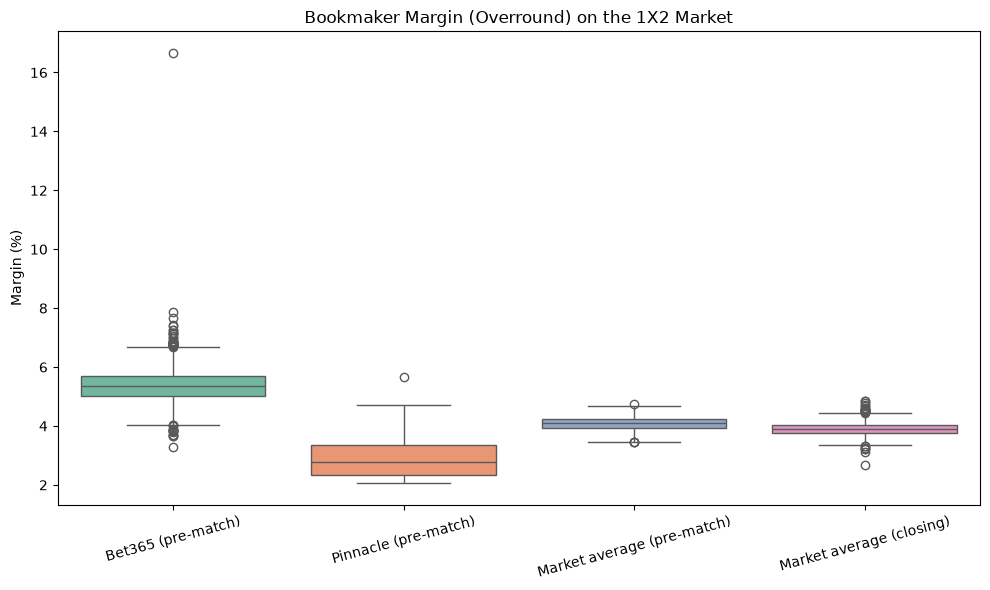

Bet365 (pre-match)            5.39
Pinnacle (pre-match)          2.90
Market average (pre-match)    4.09
Market average (closing)      3.91
dtype: float64


In [11]:
sources = {
    'Bet365 (pre-match)': ['b365_h', 'b365_d', 'b365_a'],
    'Pinnacle (pre-match)': ['psh', 'psd', 'psa'],
    'Market average (pre-match)': ['avg_h', 'avg_d', 'avg_a'],
    'Market average (closing)': ['avg_ch', 'avg_cd', 'avg_ca'],
}

margins = {}
for name, cols in sources.items():
    if all(c in df.columns for c in cols):
        margins[name] = (1 / df[cols[0]] + 1 / df[cols[1]] + 1 / df[cols[2]] - 1) * 100
margins = pd.DataFrame(margins)

plt.figure(figsize=(10, 6))
sns.boxplot(data=margins, palette='Set2')
plt.title('Bookmaker Margin (Overround) on the 1X2 Market')
plt.ylabel('Margin (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(margins.mean().round(2))

Next I look inside the fitted model. The Dixon-Coles model gives every team an attack and a defence parameter. A higher attack value means the team scores more, while a higher defence value means the team concedes more, so I flip the y-axis so that the best teams (strong attack, strong defence) appear in the top right.

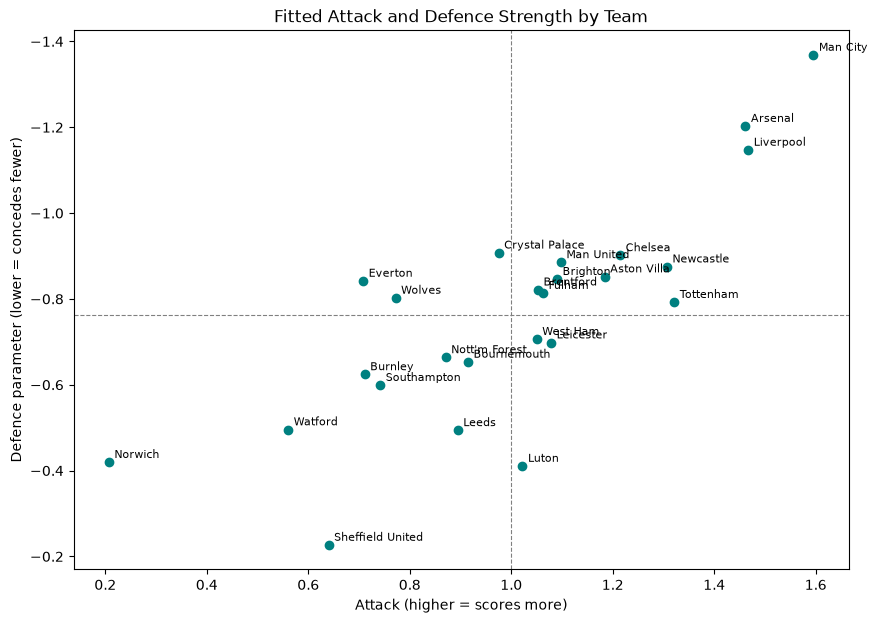

In [12]:
params = pd.Series(model.params)
team_names = sorted(model.teams)
strengths = pd.DataFrame({
    'attack': [params['attack_' + t] for t in team_names],
    'defence': [params['defence_' + t] for t in team_names],
}, index=team_names)

plt.figure(figsize=(10, 7))
plt.scatter(strengths['attack'], strengths['defence'], color='teal')
for team, row in strengths.iterrows():
    plt.annotate(team, (row['attack'], row['defence']), fontsize=8, xytext=(4, 3), textcoords='offset points')
plt.gca().invert_yaxis()
plt.axhline(strengths['defence'].mean(), color='grey', linestyle='--', linewidth=0.8)
plt.axvline(strengths['attack'].mean(), color='grey', linestyle='--', linewidth=0.8)
plt.title('Fitted Attack and Defence Strength by Team')
plt.xlabel('Attack (higher = scores more)')
plt.ylabel('Defence parameter (lower = concedes fewer)')
plt.show()

The model output for a fixture is a grid of scoreline probabilities, and every market in the example is calculated from it. I plot this grid as a heatmap for the Man City v Liverpool fixture, limited to 0-5 goals for each side to keep it readable.

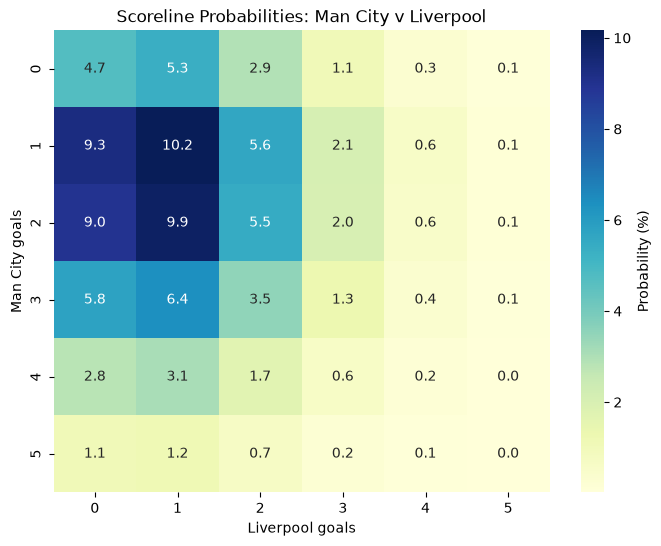

In [13]:
max_show = 6
grid = pred.grid[:max_show, :max_show] * 100

plt.figure(figsize=(8, 6))
sns.heatmap(grid, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Probability (%)'})
plt.title(f'Scoreline Probabilities: {home_team} v {away_team}')
plt.xlabel(f'{away_team} goals')
plt.ylabel(f'{home_team} goals')
plt.show()

The example fits and predicts on the same matches, which flatters the model. To test it properly I keep the most recent season as unseen test data, fit a new model on the earlier seasons only, and compare its predictions with the bookmakers' probabilities for each match. I use the market average closing odds (falling back to pre-match odds if closing odds are missing) and remove the margin with Shin's method, which is one of the options in `pb.implied.calculate_implied`. Here is a scatter plot of the two estimates of the probability of a home win, where a point on the diagonal means the model and bookmakers agree.

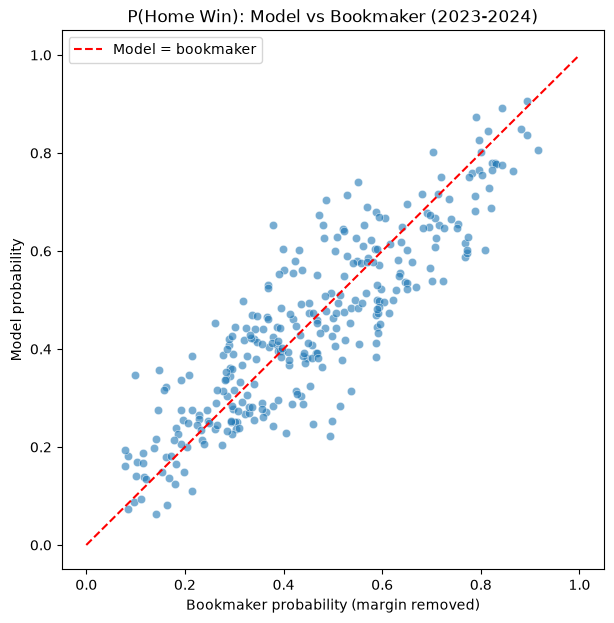

In [14]:
odds_cols = ['avg_ch', 'avg_cd', 'avg_ca']
if not all(c in df.columns for c in odds_cols):
    odds_cols = ['avg_h', 'avg_d', 'avg_a']

test_season = sorted(df['season'].unique())[-1]
train = df[df['season'] != test_season]
test = df[df['season'] == test_season].dropna(subset=odds_cols)

model_oos = pb.models.DixonColesGoalModel(
    train['goals_home'].values, train['goals_away'].values,
    train['team_home'].values, train['team_away'].values,
    weights=pb.models.dixon_coles_weights(train['date'], xi=xi),
)
model_oos.fit()

# Only keep test matches where both teams appeared in the training data (promoted teams are unknown to the model)
known = set(model_oos.teams)
test = test[test['team_home'].isin(known) & test['team_away'].isin(known)]

outcome_map = {'H': 0, 'D': 1, 'A': 2}
rows = []
for _, match in test.iterrows():
    p_model = model_oos.predict(match['team_home'], match['team_away']).home_draw_away
    p_book = pb.implied.calculate_implied(list(match[odds_cols]), method='shin').probabilities
    rows.append(list(p_model) + list(p_book) + [outcome_map[match['ftr']]])

results = pd.DataFrame(rows, columns=['model_h', 'model_d', 'model_a', 'book_h', 'book_d', 'book_a', 'outcome'])

plt.figure(figsize=(7, 7))
sns.scatterplot(data=results, x='book_h', y='model_h', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Model = bookmaker')
plt.title(f'P(Home Win): Model vs Bookmaker ({test_season})')
plt.xlabel('Bookmaker probability (margin removed)')
plt.ylabel('Model probability')
plt.legend()
plt.show()

Finally, I check who is more accurate. The left plot is a calibration curve for the home win probability: matches are grouped into five bins by predicted probability, and the actual home win rate in each bin is plotted against the average prediction, so a well-calibrated forecaster follows the diagonal. On the right I compare the two forecasters using the Ranked Probability Score (RPS) from `pb.metrics`, where lower is better.

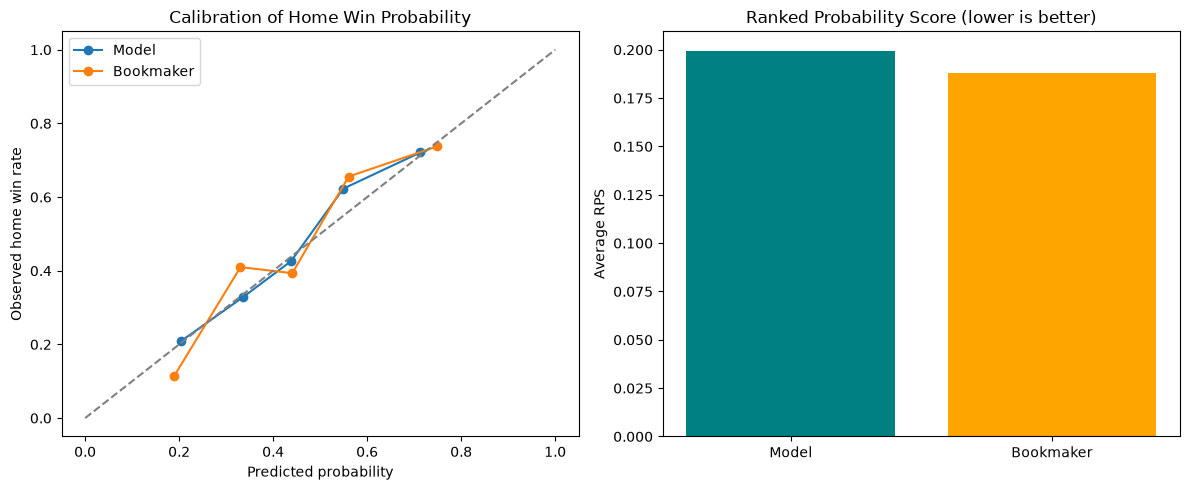

RPS  model: 0.1996   bookmaker: 0.1882   (306 matches)


In [15]:
results['home_win'] = (results['outcome'] == 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for prefix, label in [('model', 'Model'), ('book', 'Bookmaker')]:
    bins = pd.qcut(results[f'{prefix}_h'], q=5, duplicates='drop')
    calib = results.groupby(bins).agg(predicted=(f'{prefix}_h', 'mean'), actual=('home_win', 'mean'))
    axes[0].plot(calib['predicted'], calib['actual'], marker='o', label=label)
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[0].set_title('Calibration of Home Win Probability')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Observed home win rate')
axes[0].legend()

rps_model = pb.metrics.rps_average(results[['model_h', 'model_d', 'model_a']].values, results['outcome'].values)
rps_book = pb.metrics.rps_average(results[['book_h', 'book_d', 'book_a']].values, results['outcome'].values)
axes[1].bar(['Model', 'Bookmaker'], [rps_model, rps_book], color=['teal', 'orange'])
axes[1].set_title('Ranked Probability Score (lower is better)')
axes[1].set_ylabel('Average RPS')

plt.tight_layout()
plt.show()
print(f'RPS  model: {rps_model:.4f}   bookmaker: {rps_book:.4f}   ({len(results)} matches)')